# Iterative Closest Point (ICP)

## The Point Cloud Registration Problem

Given two point sets $\mathcal{X} = \{x_i\}_{i=1}^m$ and $\mathcal{Y} = \{y_j\}_{j=1}^n$, **rigid registration** seeks a rotation $R$ and translation $t$ minimizing:
$$\min_{R \in \mathrm{SO}(d),\, t \in \mathbb{R}^d} \sum_{i=1}^m \|R x_i + t - y_{\sigma(i)}\|^2$$

where $\sigma(i)$ assigns each source point to a target point. Since $\sigma$ is unknown, the problem is non-convex.

## The ICP Algorithm

**ICP** (Besl & McKay, 1992) alternates between two steps:

1. **Correspondence**: for each $x_i$, find the nearest neighbor in $\mathcal{Y}$:
   $$y_{\sigma(i)} = \arg\min_{y \in \mathcal{Y}} \|R x_i + t - y\|$$

2. **Registration**: solve the optimal rigid motion for the current correspondences:
   $$\min_{R,t} \sum_i \|R x_i + t - y_{\sigma(i)}\|^2$$

   The optimal translation is $t^* = \bar{y} - R^* \bar{x}$ (centroid alignment), and $R^*$ is obtained from the SVD of the cross-covariance matrix:
   $$M = \sum_i (x_i - \bar{x})(y_{\sigma(i)} - \bar{y})^T, \quad M = U \Sigma V^T, \quad R^* = V U^T$$

ICP is guaranteed to decrease the energy at each iteration, but may converge to a local minimum.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from ipywidgets import interact, IntSlider

### Generating 2D point clouds

We sample points from simple 2D shapes (ellipse, square, star). The target is the original shape; the source is the same shape transformed by a known rotation and translation, possibly with added noise.

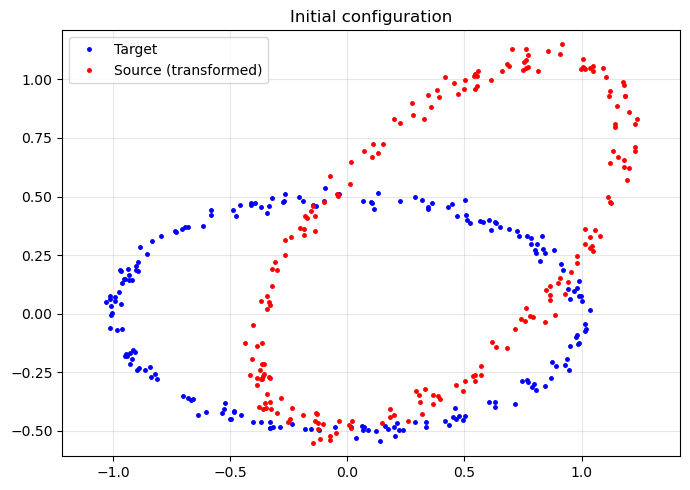

In [2]:
rng = np.random.default_rng(42)
n_pts = 200

def sample_ellipse(n, a=1.0, b=0.5, noise=0.02, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    t = rng.uniform(0, 2*np.pi, n)
    x = a * np.cos(t) + noise * rng.standard_normal(n)
    y = b * np.sin(t) + noise * rng.standard_normal(n)
    return np.column_stack([x, y])

target = sample_ellipse(n_pts, a=1.0, b=0.5, rng=rng)

# Apply a known rotation + translation to get source
theta_true = 0.8   # radians
t_true = np.array([0.4, 0.3])
R_true = np.array([[np.cos(theta_true), -np.sin(theta_true)],
                   [np.sin(theta_true),  np.cos(theta_true)]])
source = (R_true @ target.T).T + t_true + 0.02 * rng.standard_normal((n_pts, 2))

plt.figure(figsize=(7, 5))
plt.plot(*target.T, 'b.', ms=5, label='Target')
plt.plot(*source.T, 'r.', ms=5, label='Source (transformed)')
plt.legend(); plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.title('Initial configuration'); plt.tight_layout()
plt.savefig('icp_init.png', dpi=100, bbox_inches='tight'); plt.show()

### ICP implementation

We implement the full ICP loop with the SVD-based rotation solver. A KD-tree is used for efficient nearest-neighbor queries (O($n \log n$) per iteration instead of O($n^2$)).

In [3]:
def fit_rigid(X, Y):
    """Optimal rotation and translation mapping X -> Y."""
    mx = X.mean(axis=0); my = Y.mean(axis=0)
    M = (Y - my).T @ (X - mx)
    U, _, Vt = np.linalg.svd(M)
    # Ensure proper rotation (det = +1)
    D = np.diag([1, np.linalg.det(U @ Vt)])
    R = U @ D @ Vt
    t = my - R @ mx
    return R, t

def icp(source, target, n_iter=30):
    """Run ICP and return trajectory of (R, t, error) per iteration."""
    tree = cKDTree(target)
    X = source.copy()
    R_total = np.eye(2)
    t_total = np.zeros(2)
    history = []
    for it in range(n_iter):
        # Step 1: Find correspondences
        dists, indices = tree.query(X)
        Y_corr = target[indices]
        err = np.mean(dists**2)
        history.append({'X': X.copy(), 'err': err, 'R': R_total.copy(), 't': t_total.copy()})
        # Step 2: Solve rigid alignment
        R, t = fit_rigid(X, Y_corr)
        X = (R @ X.T).T + t
        R_total = R @ R_total
        t_total = R @ t_total + t
        if err < 1e-8:
            break
    return history

history = icp(source, target, n_iter=30)

### Convergence visualization

ICP converges geometrically to the correct alignment (when the initialization is close enough). We show several snapshots of the alignment process.

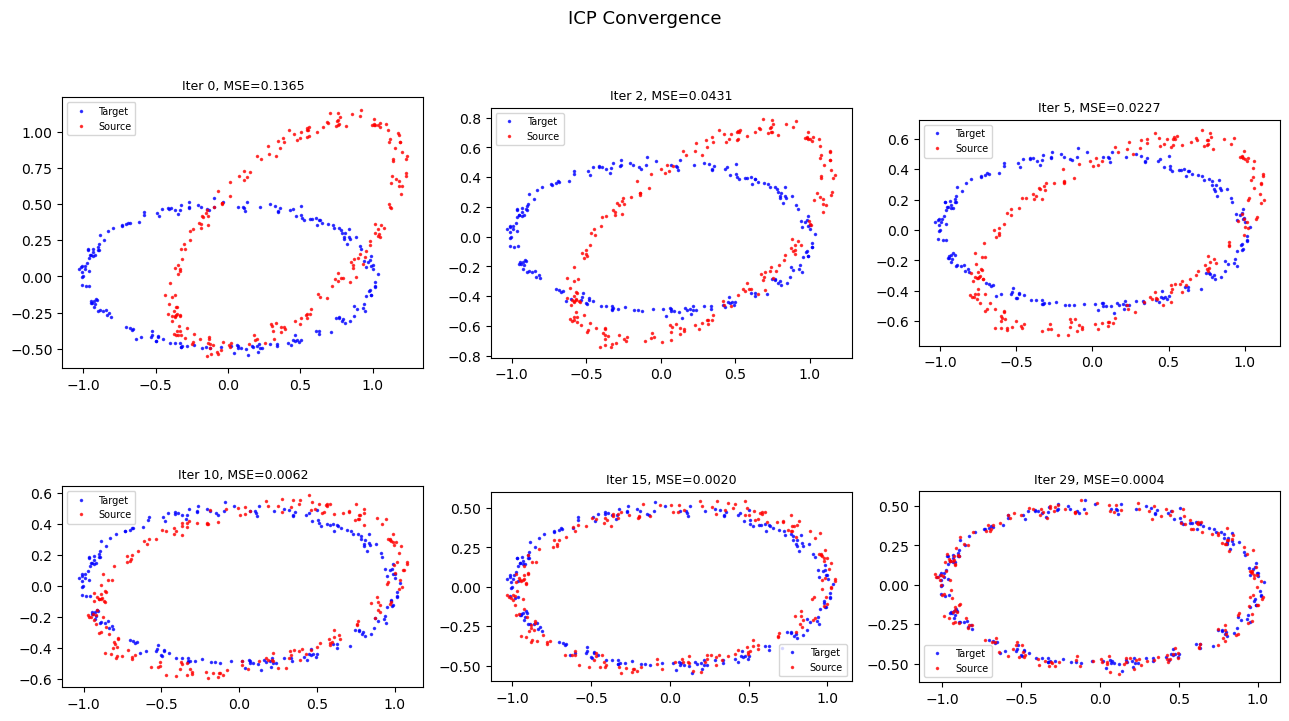

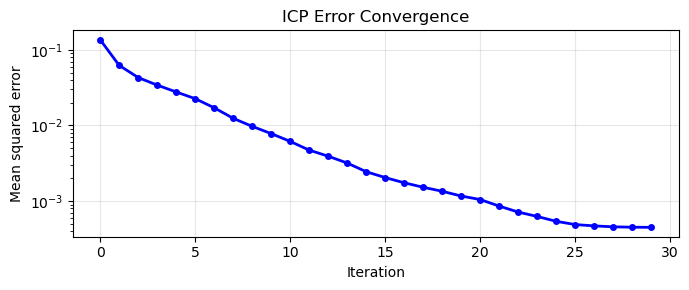

In [4]:
snap_iters = [0, 2, 5, 10, 15, len(history)-1]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, it in zip(axes.ravel(), snap_iters):
    h = history[min(it, len(history)-1)]
    ax.plot(*target.T, 'b.', ms=3, alpha=0.7, label='Target')
    ax.plot(*h['X'].T, 'r.', ms=3, alpha=0.7, label='Source')
    ax.set_title(f'Iter {it}, MSE={h["err"]:.4f}', fontsize=9)
    ax.set_aspect('equal'); ax.legend(fontsize=7)
plt.suptitle('ICP Convergence', fontsize=13)
plt.tight_layout(); plt.savefig('icp_convergence.png', dpi=100, bbox_inches='tight'); plt.show()

errors = [h['err'] for h in history]
plt.figure(figsize=(7, 3))
plt.semilogy(errors, 'o-b', lw=2, ms=4)
plt.xlabel('Iteration'); plt.ylabel('Mean squared error')
plt.title('ICP Error Convergence'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('icp_error.png', dpi=100, bbox_inches='tight'); plt.show()

### Sensitivity to initialization

ICP is a local method: it can get stuck in a local minimum if the initial rotation is too large. We run ICP from several random initializations to illustrate this.

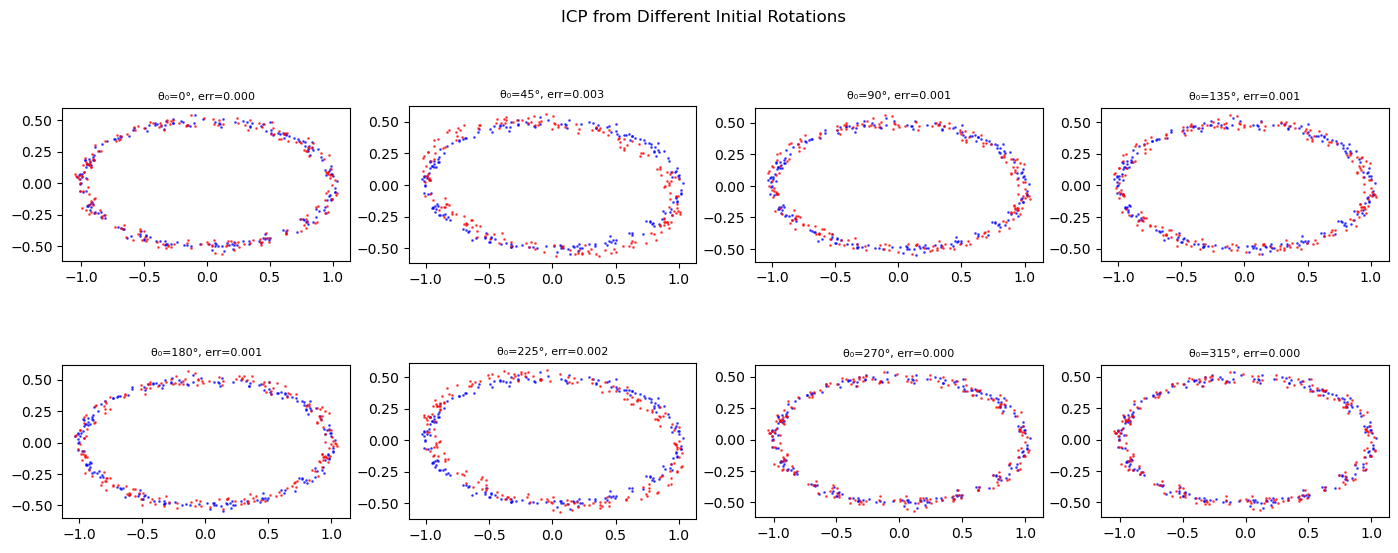

In [5]:
rng2 = np.random.default_rng(7)
init_angles = np.linspace(0, 2*np.pi, 8, endpoint=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, angle in zip(axes.ravel(), init_angles):
    R_init = np.array([[np.cos(angle), -np.sin(angle)],
                       [np.sin(angle),  np.cos(angle)]])
    src_init = (R_init @ source.T).T
    hist = icp(src_init, target, n_iter=30)
    final_err = hist[-1]['err']
    ax.plot(*target.T, 'b.', ms=2, alpha=0.6)
    ax.plot(*hist[-1]['X'].T, 'r.', ms=2, alpha=0.6)
    ax.set_title(f'θ₀={np.degrees(angle):.0f}°, err={final_err:.3f}', fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('ICP from Different Initial Rotations', fontsize=12)
plt.tight_layout(); plt.savefig('icp_init_sens.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: step through ICP iterations

In [ ]:
def show_icp_step(iteration=0):
    h = history[min(iteration, len(history)-1)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(*target.T, 'b.', ms=4, alpha=0.7, label='Target')
    axes[0].plot(*h['X'].T, 'r.', ms=4, alpha=0.7, label='Source')
    axes[0].set_title(f'Iteration {iteration}, MSE = {h["err"]:.5f}')
    axes[0].set_aspect('equal'); axes[0].legend()
    axes[1].semilogy([hh['err'] for hh in history], 'b-o', ms=4)
    axes[1].axvline(iteration, color='r', linestyle='--')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('MSE'); axes[1].set_title('Error curve')
    plt.tight_layout(); plt.show()

interact(show_icp_step, iteration=IntSlider(min=0, max=len(history)-1, step=1, value=0));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    for ax, it in zip(axes.ravel(), snap_iters):
        h = history[min(it, len(history)-1)]
        ax.plot(*target.T, 'b.', ms=3, alpha=0.7)
        ax.plot(*h['X'].T, 'r.', ms=3, alpha=0.7)
        ax.set_title(f'Iter {it}, MSE={h["err"]:.4f}', fontsize=9)
        ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- ICP alternates nearest-neighbor matching with SVD-based rigid alignment — each step is guaranteed to reduce the error.
- The SVD registration sub-step is the **closed-form solution to the orthogonal Procrustes problem**.
- ICP converges to a local minimum; good initialization is critical for non-convex cases.
- Extensions include point-to-plane ICP, probabilistic ICP, and global registration via FPFH descriptors.

## Bibliography

- P. Besl & N. McKay, *A method for registration of 3-D shapes*, IEEE TPAMI 14(2), 1992.
- Z. Zhang, *Iterative point matching for registration of free-form curves*, IJCV 13(2), 1994.
- R. Rusu, N. Blodow & M. Beetz, *Fast Point Feature Histograms*, ICRA 2009.